# Big Data Analysis

Task one by Muhammad Farras Ma'ru S.Ak.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\maruf\.cache\kagglehub\datasets\ahmedmohamed2003\retail-store-sales-dirty-for-data-cleaning\versions\1


In [54]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

In [3]:
dirty_data = pd.read_csv(r''+path+'/retail_store_sales.csv')

Display Data

In [4]:
dirty_data.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [5]:
dirty_data.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [6]:
dirty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [7]:
dirty_data.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


## Missing Value

The data has 12575 record and 10 columns. There 5 columns which has missing data such as 
1. Item
2. Price per Unit
3. Quantity
4. Total Spent
5. And discount applied

In this part is for handle the missing data and menymaratakan tipe data pada kolom

### Price per Unit

In [8]:
dirty_data['Price Per Unit'].isnull().sum()

np.int64(609)

Banyak nilai missing pada kolom price per unit sebanyak 609 data

In [9]:
dirty_data['Price Per Unit'].unique()

array([18.5, 29. , 21.5, 27.5, 12.5,  nan,  5. , 33.5, 36.5,  8. ,  6.5,
       39.5, 24.5, 23. , 35. , 14. ,  9.5, 41. , 20. , 38. , 15.5, 11. ,
       32. , 26. , 30.5, 17. ])

Dari keunikan data, kolom Price Per Unit semuanya memiliki tipe float dan sisanya missing value `nan`

In [10]:
dirty_data[dirty_data['Price Per Unit'].isnull()].head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
17,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
21,TXN_8685338,CUST_15,Milk Products,NaN,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,NaN
32,TXN_1543244,CUST_20,Food,NaN,NaN,8.0,196.0,Credit Card,Online,2024-10-25,True


Dari table yang mengadung nilai missing value pada kolom Price Per Unit terdapat informasi `Quantity` dan `Total Spent` yang mana dapat digunakan untuk mengetahui nilai `Price Per Unit`. Price Per Unit = Total Spent / Quantity. Namun kolom quantity dan total spent juga terdapat missing data, maka dari itu untuk mengisi Price Per Unit harus memenuhi syarat nilai Quantity dan Total Spent harus memiliki nilai.

In [11]:
print(f"Price per Unit Missing Value : {dirty_data['Price Per Unit'].isnull().sum()}")
print(f"Price Per Unit Miss Value & (Quantity & Total Sepent) has value {(dirty_data['Price Per Unit'].isnull() & dirty_data['Quantity'].notnull() & dirty_data['Total Spent'].notnull()).sum()}")


Price per Unit Missing Value : 609
Price Per Unit Miss Value & (Quantity & Total Sepent) has value 609


Dapat diartikan dari inspeksi diatas bahwa tidak ada data Price Per Unit yang nilainya missing dan nilai Quantity dan Total Spent juga missing. Artinya kita dapat memenuhi semua missing value dengan membagi Total Spent dengan Quantity

In [12]:
mask = dirty_data['Price Per Unit'].isnull()
dirty_data.loc[mask,'Price Per Unit'] = (dirty_data.loc[mask,'Total Spent'] / dirty_data.loc[mask,'Quantity'])

In [13]:
dirty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Okeh, data Price Per Unit seluruhnya sudah terisi, tidak ada lagi data NaN dan tipe data sudah seragam, FLOAT64

In [14]:
dirty_data['Price Per Unit'].unique()

array([18.5, 29. , 21.5, 27.5, 12.5, 20. ,  5. , 33.5, 36.5,  8. ,  6.5,
       39.5, 24.5, 23. , 35. , 14. ,  9.5, 41. , 38. , 15.5, 11. , 32. ,
       26. , 30.5, 17. ])

### Quantity

In [15]:
dirty_data['Quantity'].unique()

array([10.,  9.,  2.,  7.,  8., nan,  1.,  3.,  6.,  4.,  5.])

In [16]:
print(dirty_data.Quantity.isnull().sum())

604


pada kolom Quantity terdapat 604 data missing, dan data yang seragam dari 1 - 10. Berdasarkan interpretasi keunikan data dan nama kolom seharusnya tipe data adala Integer (Bilangan bulat)

In [17]:
mask_na_quantity = dirty_data.Quantity.isnull()
mask_na_quantity_with_ppu_ts = dirty_data.Quantity.isnull() & dirty_data['Price Per Unit'].notnull() & dirty_data['Total Spent'].notnull()

In [18]:
dirty_data[mask_na_quantity].tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12527,TXN_1069238,CUST_23,Food,NaN,5.0,NaN,NaN,Digital Wallet,In-store,2022-08-13,False
12552,TXN_4823896,CUST_05,Milk Products,NaN,8.0,NaN,NaN,Cash,In-store,2022-07-21,False
12556,TXN_4397672,CUST_04,Beverages,NaN,41.0,NaN,NaN,Credit Card,Online,2024-11-28,True
12562,TXN_7422454,CUST_07,Butchers,NaN,33.5,NaN,NaN,Cash,Online,2023-04-15,NaN
12564,TXN_2153066,CUST_17,Electric household essentials,NaN,29.0,NaN,NaN,Digital Wallet,In-store,2024-03-28,False


In [19]:
dirty_data[mask_na_quantity_with_ppu_ts].Quantity.sum()

np.float64(0.0)

Kolom Quantity tidak dapat diproduce menggunakan persamaan Total Spent dibagi dengan Price Per Unit karena syarat nilai Total Spent memiliki nilai tidak terpenuhi. Ada cara lain untuk mengisi nilai missing value dengan cara mengambil nilai rata2 dari category yang sama.

In [20]:
mask_not_null_quantity = dirty_data.Quantity.notnull()
print(dirty_data[mask_not_null_quantity].Category.unique())
print(dirty_data[mask_na_quantity].Category.unique())

['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']
['Furniture' 'Beverages' 'Patisserie' 'Computers and electric accessories'
 'Butchers' 'Food' 'Electric household essentials' 'Milk Products']


In [21]:
counter = 0;
maps_average_per_category = {}
for a in dirty_data[mask_not_null_quantity].Category.unique():
    temp_mask = dirty_data[mask_not_null_quantity].Category == a
    sum_per_category = dirty_data[mask_not_null_quantity][temp_mask].Quantity.sum()
    count_per_category = dirty_data[mask_not_null_quantity][temp_mask].Quantity.count()
    counter += sum_per_category
    maps_average_per_category[a] = np.round(sum_per_category / count_per_category)
    print(f"{a} : {count_per_category}")

print(f"Total : {counter}")

Patisserie : 1441
Milk Products : 1513
Butchers : 1496
Beverages : 1496
Food : 1507
Furniture : 1525
Electric household essentials : 1516
Computers and electric accessories : 1477
Total : 66276.0


In [22]:
maps_average_per_category

{'Patisserie': np.float64(6.0),
 'Milk Products': np.float64(6.0),
 'Butchers': np.float64(5.0),
 'Beverages': np.float64(6.0),
 'Food': np.float64(6.0),
 'Furniture': np.float64(6.0),
 'Electric household essentials': np.float64(5.0),
 'Computers and electric accessories': np.float64(6.0)}

In [23]:
dirty_data['Quantity'] = dirty_data['Quantity'].fillna(dirty_data.Category.map(maps_average_per_category))

In [24]:
dirty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [25]:
dirty_data.Quantity.unique()

array([10.,  9.,  2.,  7.,  8.,  6.,  1.,  3.,  4.,  5.])

### Total Spent

In [26]:
mask_na_total_spen = dirty_data['Total Spent'].isnull()
mask_not_null_total_spen = dirty_data['Total Spent'].notnull()

In [27]:
print(mask_na_total_spen.sum())

604


In [28]:
dirty_data['Total Spent'].unique()

array([185. , 261. ,  43. , 247.5,  87.5, 200. ,  40. ,   nan,  27.5,
       109.5,  72. ,  52. ,  45.5, 237. ,  55. , 232. , 275. ,  23. ,
       126. , 105. ,  66.5,  18.5,  49. , 134. , 410. , 245. , 182.5,
       100. , 196. , 315. , 287. ,  76. ,  92.5, 190. , 255.5, 276.5,
        46.5,   8. , 107.5, 165. ,  80. , 192.5, 335. ,  66. , 215. ,
        96. ,  42. ,  11. , 234. , 316. ,  82.5, 180. , 365. ,  39. ,
       172. , 122. ,  30. ,  84. , 320. , 219. ,  67. , 146. , 290. ,
        70. , 160. ,  82. ,  14. , 355.5, 124. ,  28.5,  47.5, 193.5,
        38. ,  12.5, 140. , 120. , 183. , 305. ,  41. , 155. ,  19.5,
        33. , 108.5, 119. , 280. ,  62. ,  32. , 380. , 304. , 139.5,
       114. , 192. , 167.5,  88. , 395. , 158. ,  25. ,  50. ,  32.5,
        15. ,  33.5,  24. , 111. ,  46. ,  36.5,  62.5, 161. ,  26. ,
        98. ,  85. , 228. ,  91.5,  93. ,  35. , 208. , 100.5,   9.5,
        10. , 138. , 288. ,  60. , 123. ,  73. , 197.5,  69. ,  61. ,
       116. ,  55.5,

Nilai dari kolom `Total Spent` beragam, berdasarkan interpretasi diatas kolom ini memiliki tipe float. Namun ada data tipe nan atau missing value yang dapat kita generate menggunakan kolom `Quantity` dan `Price Per Unit`

In [29]:
dirty_data.loc[mask_na_total_spen, 'Total Spent'] = dirty_data.loc[mask_na_total_spen, 'Quantity'] * dirty_data.loc[mask_na_total_spen, 'Price Per Unit'] 

In [30]:
dirty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


### Item

In [31]:
mask_na_item = dirty_data.Item.isnull()
print(mask_na_item.sum())

1213


In [32]:
dirty_data.Item.unique()

array(['Item_10_PAT', 'Item_17_MILK', 'Item_12_BUT', 'Item_16_BEV',
       'Item_6_FOOD', nan, 'Item_1_FOOD', 'Item_16_FUR', 'Item_22_BUT',
       'Item_3_BUT', 'Item_2_FOOD', 'Item_24_PAT', 'Item_16_MILK',
       'Item_17_PAT', 'Item_13_EHE', 'Item_7_BEV', 'Item_4_EHE',
       'Item_10_FOOD', 'Item_14_FUR', 'Item_20_BUT', 'Item_25_FUR',
       'Item_14_FOOD', 'Item_22_PAT', 'Item_11_FOOD', 'Item_6_PAT',
       'Item_21_EHE', 'Item_25_BEV', 'Item_23_FOOD', 'Item_10_FUR',
       'Item_11_BEV', 'Item_23_BUT', 'Item_22_BEV', 'Item_10_EHE',
       'Item_24_BUT', 'Item_8_BEV', 'Item_3_FOOD', 'Item_12_FOOD',
       'Item_16_CEA', 'Item_11_PAT', 'Item_16_BUT', 'Item_5_CEA',
       'Item_19_MILK', 'Item_23_FUR', 'Item_7_FUR', 'Item_15_CEA',
       'Item_6_MILK', 'Item_24_CEA', 'Item_22_CEA', 'Item_22_FOOD',
       'Item_2_BUT', 'Item_14_PAT', 'Item_12_PAT', 'Item_18_FOOD',
       'Item_1_PAT', 'Item_4_BEV', 'Item_22_FUR', 'Item_7_PAT',
       'Item_20_CEA', 'Item_20_FOOD', 'Item_11_FUR', 'Item

Semua data bertipe string dan memiliki nilai yang sangat beragam

In [33]:
dirty_data[dirty_data.Item.isnull()].tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12527,TXN_1069238,CUST_23,Food,NaN,5.0,6.0,30.0,Digital Wallet,In-store,2022-08-13,False
12552,TXN_4823896,CUST_05,Milk Products,NaN,8.0,6.0,48.0,Cash,In-store,2022-07-21,False
12556,TXN_4397672,CUST_04,Beverages,NaN,41.0,6.0,246.0,Credit Card,Online,2024-11-28,True
12562,TXN_7422454,CUST_07,Butchers,NaN,33.5,5.0,167.5,Cash,Online,2023-04-15,NaN
12564,TXN_2153066,CUST_17,Electric household essentials,NaN,29.0,5.0,145.0,Digital Wallet,In-store,2024-03-28,False


Nilati Item Null, sepertinya bisa di mapping dengan nilai category dan Price per Unit, dari sini kita bisa melakukan mapping-nya

In [34]:
dirty_data[(dirty_data.Category=='Beverages') & (dirty_data['Price Per Unit'] == 41.0)].head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
35,TXN_6398436,CUST_15,Beverages,Item_25_BEV,41.0,7.0,287.0,Credit Card,In-store,2024-06-03,True
221,TXN_1747548,CUST_04,Beverages,Item_25_BEV,41.0,2.0,82.0,Digital Wallet,Online,2024-11-06,NaN
237,TXN_7214951,CUST_04,Beverages,Item_25_BEV,41.0,5.0,205.0,Cash,In-store,2023-10-12,NaN
379,TXN_9440172,CUST_20,Beverages,Item_25_BEV,41.0,9.0,369.0,Credit Card,In-store,2023-10-25,False
869,TXN_1814138,CUST_06,Beverages,Item_25_BEV,41.0,10.0,410.0,Credit Card,In-store,2024-11-16,NaN


Ya bisa, diliat, ternyata nilai Category dan Price Per unit seragam

In [35]:
# Step 1: Build mapping (only rows with valid Item)
mapping_df = (
    dirty_data
    .dropna(subset=['Item'])
    .groupby(['Category', 'Price Per Unit'], as_index=False)['Item']
    .first()
    .rename(columns={'Item': 'Item_lookup'})
)

# Merge bersarankan Categpru da Price Per Unit
dirty_data = dirty_data.merge(
    mapping_df,
    on=['Category', 'Price Per Unit'],
    how='left'
)

# # Step 3: Fill NA
dirty_data['Item'] = dirty_data['Item'].fillna(dirty_data['Item_lookup'])

# # Step 4: Cleanup
dirty_data = dirty_data.drop(columns='Item_lookup')

In [36]:
dirty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


### Discount Applied

In [37]:
dirty_data['Discount Applied'].isnull().sum()

np.int64(4199)

In [38]:
dirty_data['Discount Applied'] = dirty_data['Discount Applied'].fillna(False)
dirty_data.head()

C:\Users\maruf\AppData\Local\Temp\ipykernel_28552\3127077152.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dirty_data['Discount Applied'] = dirty_data['Discount Applied'].fillna(False)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [39]:
dirty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  12575 non-null  bool   
dtypes: bool(1), float64(3), object(7)
memory usage: 994.8+ KB


## Penyeragaman tipe data

In [40]:
dirty_data['Transaction ID'] = dirty_data['Transaction ID'].astype('string')
dirty_data['Customer ID'] = dirty_data['Customer ID'].astype('string')
dirty_data['Category'] = dirty_data['Category'].astype('string')
dirty_data['Item'] = dirty_data['Item'].astype('string')
dirty_data['Payment Method'] = dirty_data['Payment Method'].astype('string')
dirty_data['Location'] = dirty_data['Location'].astype('string')
dirty_data['Transaction Date'] = dirty_data['Transaction Date'].astype('string')

In [41]:
dirty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  string 
 1   Customer ID       12575 non-null  string 
 2   Category          12575 non-null  string 
 3   Item              12575 non-null  string 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  string 
 8   Location          12575 non-null  string 
 9   Transaction Date  12575 non-null  string 
 10  Discount Applied  12575 non-null  bool   
dtypes: bool(1), float64(3), string(7)
memory usage: 994.8 KB


## Normalisasi Data

In [42]:
import matplotlib.pyplot as plt

### Plot sebelum normalisasi Data

#### Price Per Unit

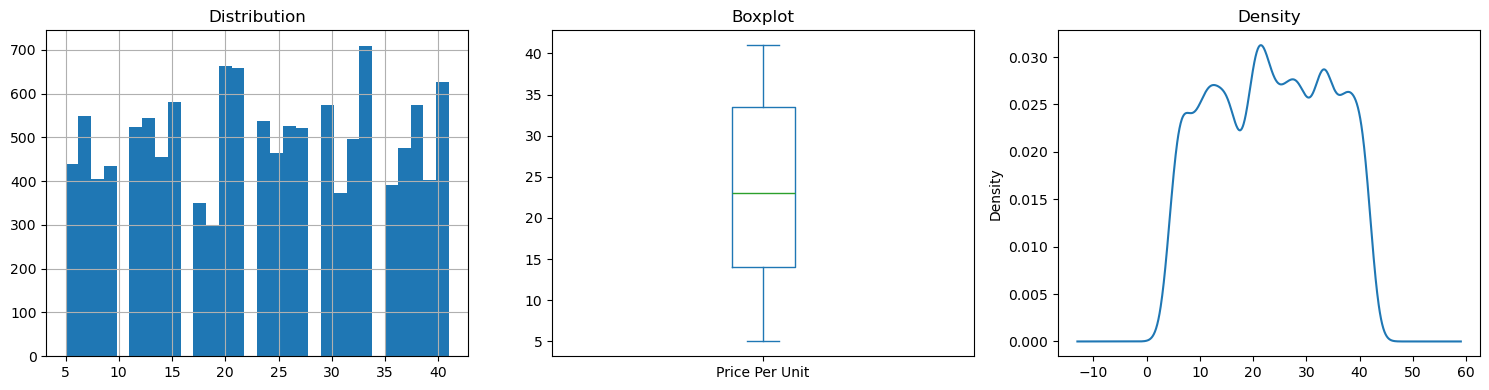

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
dirty_data['Price Per Unit'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution')

# Boxplot
dirty_data['Price Per Unit'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot')

# KDE
dirty_data['Price Per Unit'].plot(kind='kde', ax=axes[2])
axes[2].set_title('Density')

plt.tight_layout()
plt.show()

In [44]:
from scipy import stats

print("=== Distribution Quality Report ===")
print(f"Mean      : {dirty_data['Price Per Unit'].mean():.2f}")
print(f"Median    : {dirty_data['Price Per Unit'].median():.2f}")
print(f"Std Dev   : {dirty_data['Price Per Unit'].std():.2f}")
print(f"Skewness  : {dirty_data['Price Per Unit'].skew():.2f}")
print(f"Kurtosis  : {dirty_data['Price Per Unit'].kurt():.2f}")

stat, p = stats.normaltest(dirty_data['Price Per Unit'])
print(f"Normal?   : {'Yes ✅' if p > 0.05 else 'No ⚠️'}")

=== Distribution Quality Report ===
Mean      : 23.37
Median    : 23.00
Std Dev   : 10.75
Skewness  : -0.03
Kurtosis  : -1.17
Normal?   : No ⚠️


#### Quantity

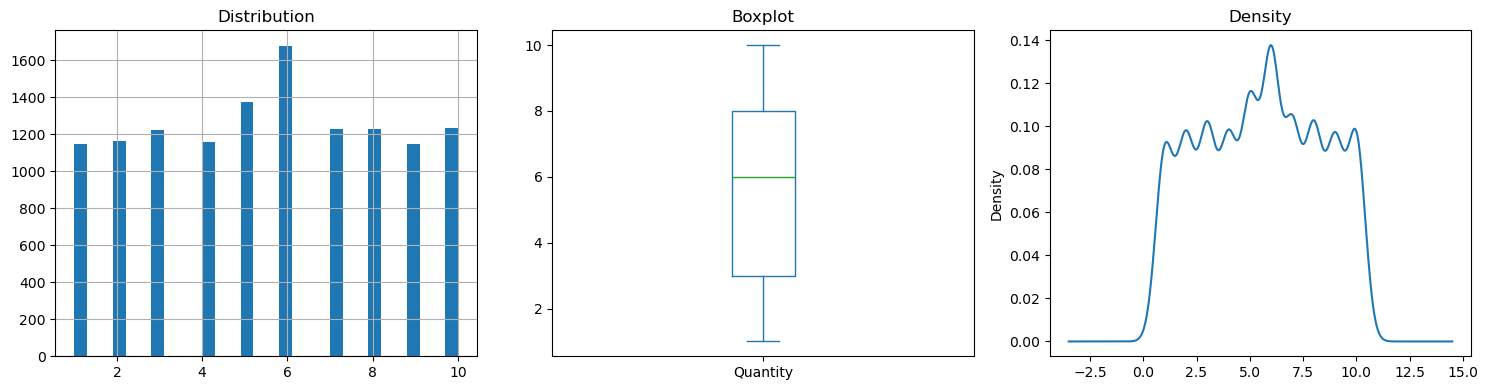

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
dirty_data['Quantity'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution')

# Boxplot
dirty_data['Quantity'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot')

# KDE
dirty_data['Quantity'].plot(kind='kde', ax=axes[2])
axes[2].set_title('Density')

plt.tight_layout()
plt.show()

In [46]:
from scipy import stats

print("=== Distribution Quality Report ===")
print(f"Mean      : {dirty_data['Quantity'].mean():.2f}")
print(f"Median    : {dirty_data['Quantity'].median():.2f}")
print(f"Std Dev   : {dirty_data['Quantity'].std():.2f}")
print(f"Skewness  : {dirty_data['Quantity'].skew():.2f}")
print(f"Kurtosis  : {dirty_data['Quantity'].kurt():.2f}")

stat, p = stats.normaltest(dirty_data['Price Per Unit'])
print(p)
print(f"Normal?   : {'Yes ✅' if p > 0.05 else 'No ⚠️'}")

=== Distribution Quality Report ===
Mean      : 5.55
Median    : 6.00
Std Dev   : 2.79
Skewness  : -0.02
Kurtosis  : -1.12
0.0
Normal?   : No ⚠️


#### Total Spent

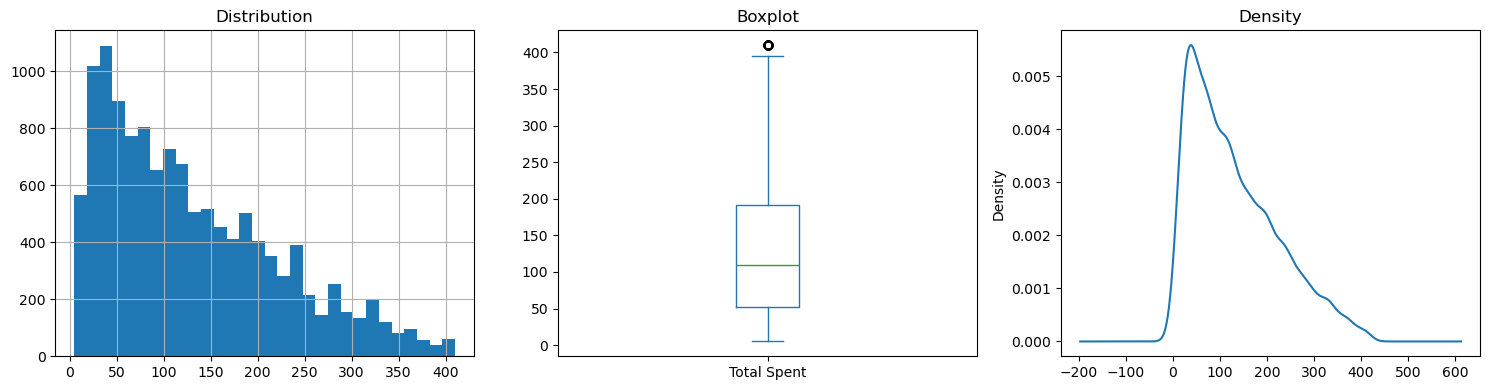

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
dirty_data['Total Spent'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution')

# Boxplot
dirty_data['Total Spent'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot')

# KDE
dirty_data['Total Spent'].plot(kind='kde', ax=axes[2])
axes[2].set_title('Density')

plt.tight_layout()
plt.show()

In [48]:
from scipy import stats

print("=== Distribution Quality Report ===")
print(f"Mean      : {dirty_data['Total Spent'].mean():.2f}")
print(f"Median    : {dirty_data['Total Spent'].median():.2f}")
print(f"Std Dev   : {dirty_data['Total Spent'].std():.2f}")
print(f"Skewness  : {dirty_data['Total Spent'].skew():.2f}")
print(f"Kurtosis  : {dirty_data['Total Spent'].kurt():.2f}")

stat, p = stats.normaltest(dirty_data['Price Per Unit'])
print (p)
print(f"Normal?   : {'Yes ✅' if p > 0.05 else 'No ⚠️'}")

=== Distribution Quality Report ===
Mean      : 129.92
Median    : 110.00
Std Dev   : 93.48
Skewness  : 0.82
Kurtosis  : -0.09
0.0
Normal?   : No ⚠️


### Menditribusikan normal data

In [59]:
distributed = dirty_data.copy()

# Log
distributed['Price Per Unit'] = np.log1p(distributed['Price Per Unit'])
distributed['Quantity'] = np.log1p(distributed['Quantity'])
distributed['Total Spent'] = np.log1p(distributed['Total Spent'])

# box cox
boxcox = dirty_data.copy()
boxcox['Price Per Unit'], lambda_ = stats.boxcox(boxcox['Price Per Unit'] + 1)
boxcox['Quantity'], lambda_ = stats.boxcox(boxcox['Quantity'] + 1)
boxcox['Total Spent'], lambda_ = stats.boxcox(boxcox['Total Spent'] + 1)

# Yoe Jhonson
yoejo = dirty_data.copy()
pt = PowerTransformer(method='yeo-johnson')
yoejo['Price Per Unit'] = pt.fit_transform(yoejo[['Price Per Unit']]).flatten()

### Plot sesudah normalisasi Data

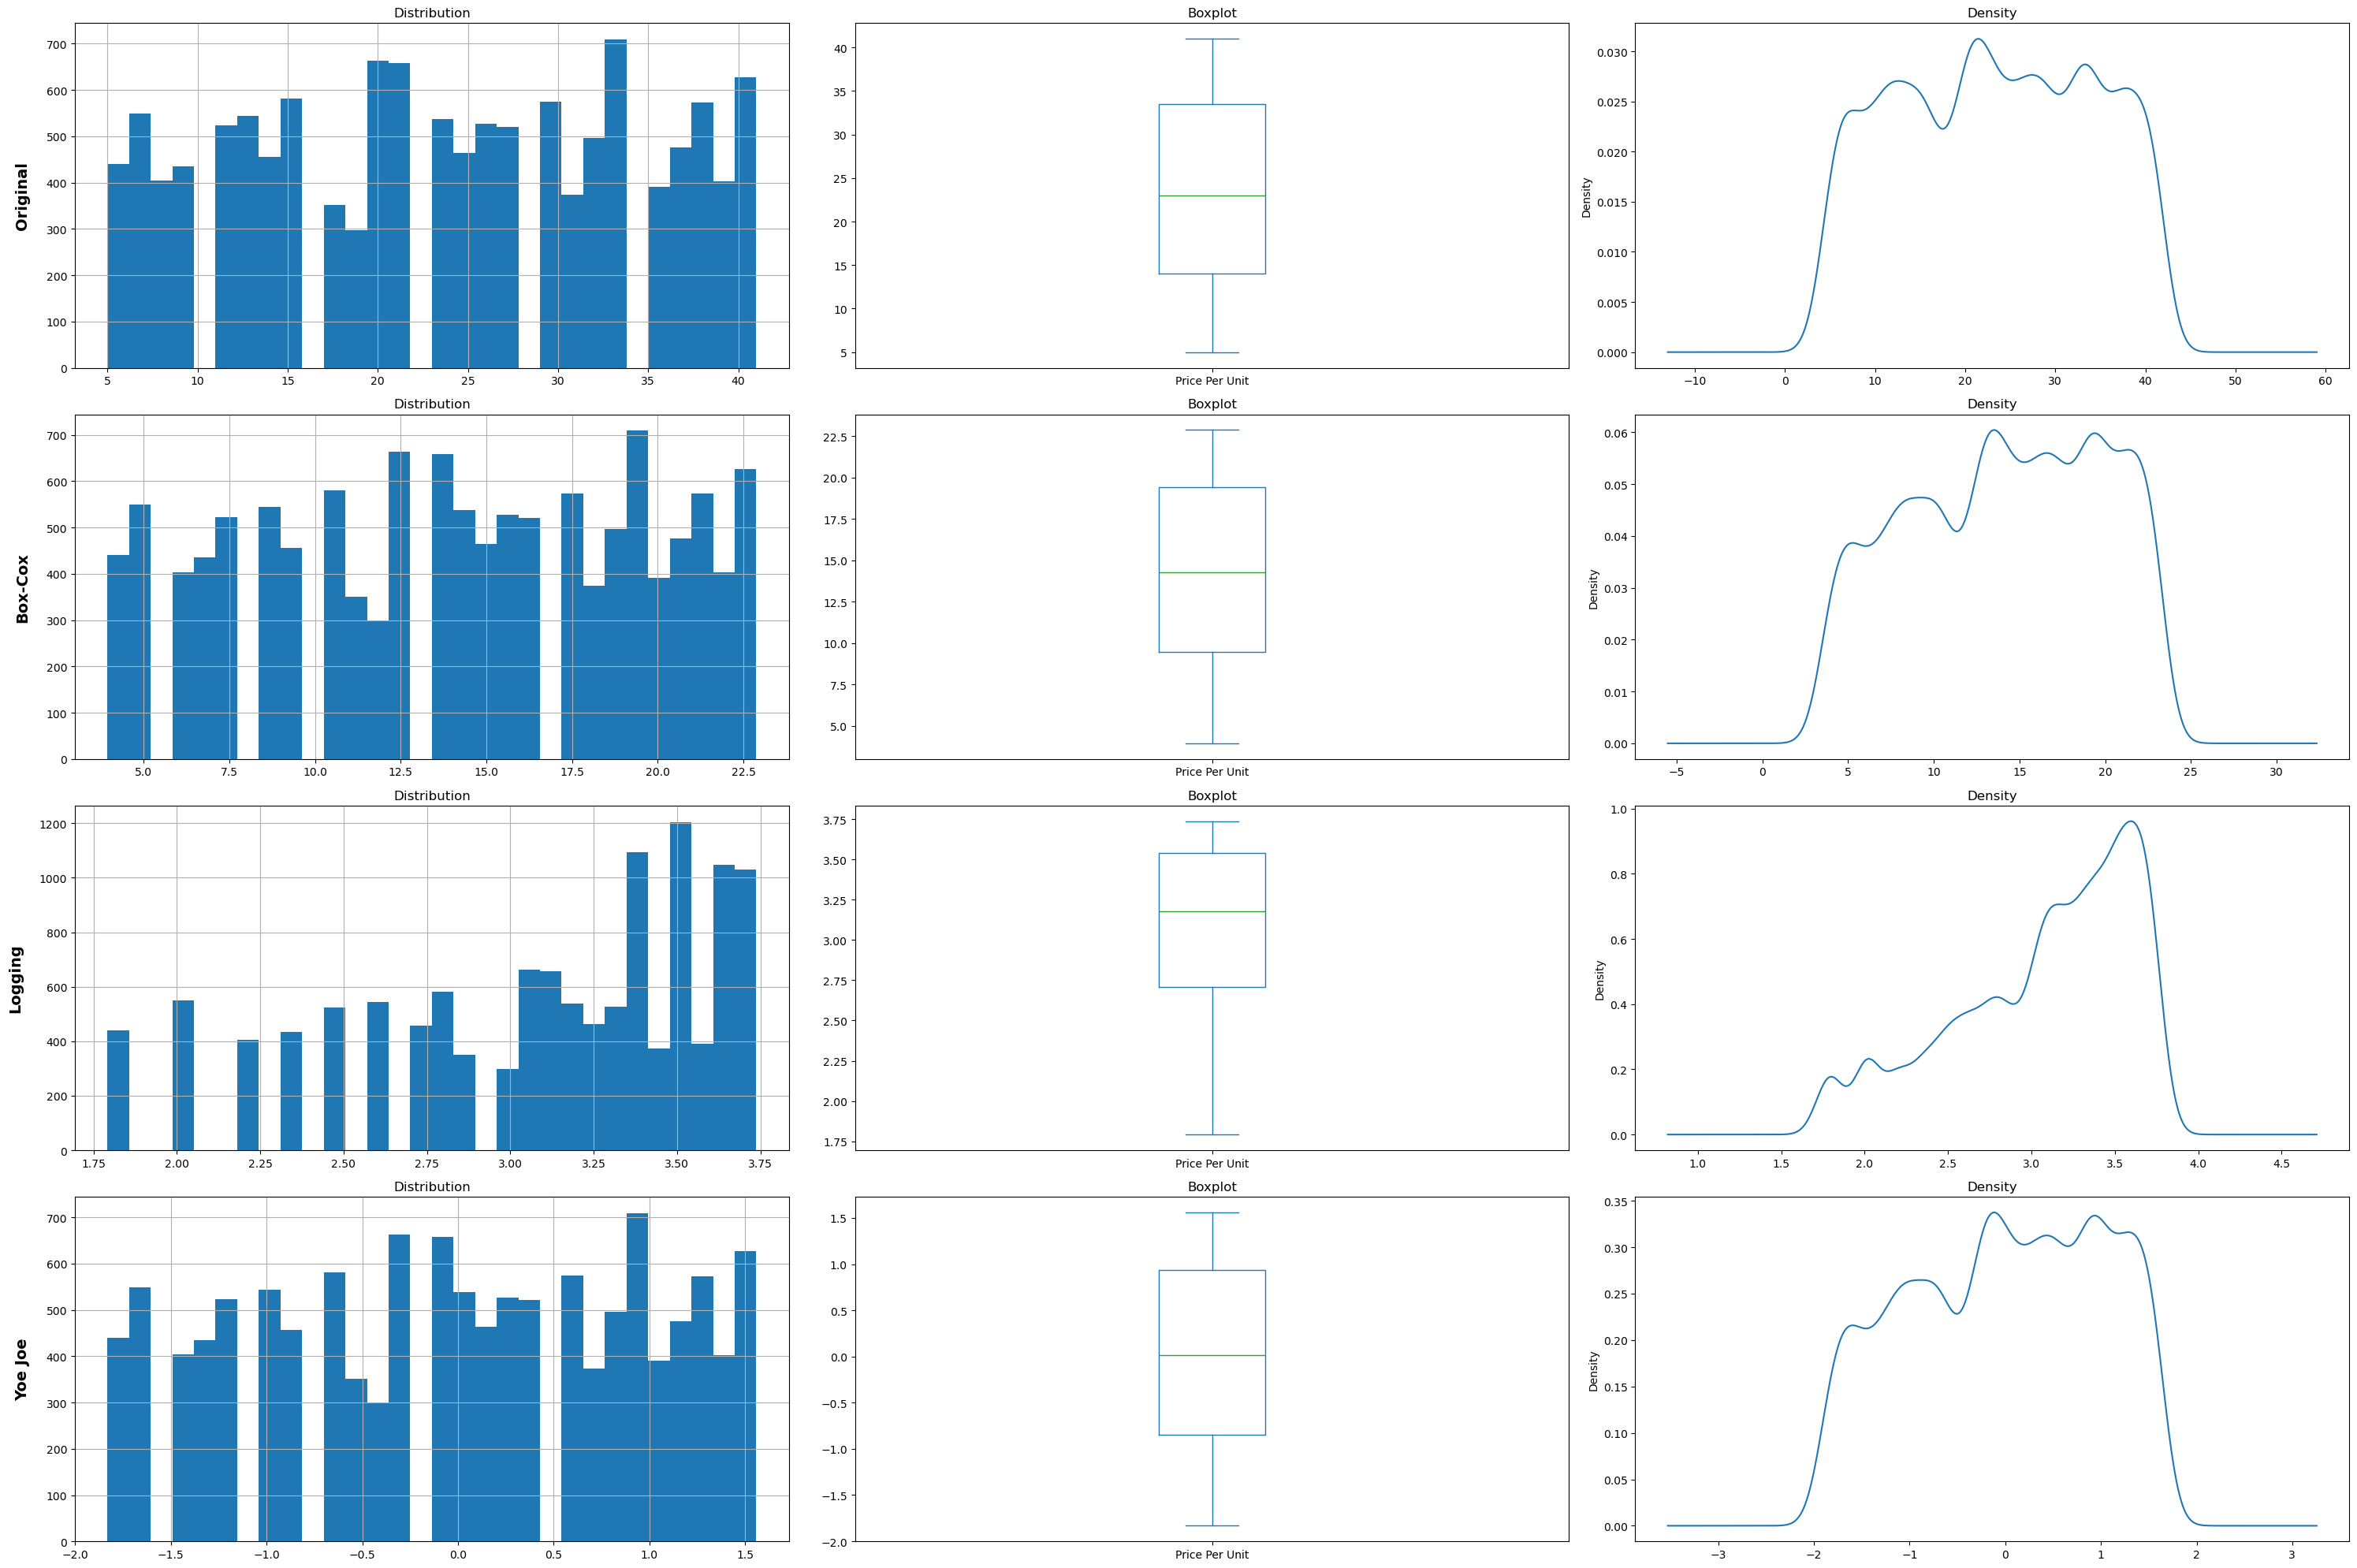

In [63]:
fig, axes = plt.subplots(4, 3, figsize=(30, 20))

###==== Normal
axes[0, 0].set_ylabel('Original', fontsize=14, fontweight='bold', labelpad=15)
# Histogram
dirty_data['Price Per Unit'].hist(bins=30, ax=axes[0,0])
axes[0,0].set_title('Distribution')

# Boxplot
dirty_data['Price Per Unit'].plot(kind='box', ax=axes[0,1])
axes[0,1].set_title('Boxplot')

# KDE
dirty_data['Price Per Unit'].plot(kind='kde', ax=axes[0,2])
axes[0,2].set_title('Density')

###==== Boxcox
axes[1, 0].set_ylabel('Box-Cox', fontsize=14, fontweight='bold', labelpad=15)
# Histogram
boxcox['Price Per Unit'].hist(bins=30, ax=axes[1,0])
axes[1,0].set_title('Distribution')

# Boxplot
boxcox['Price Per Unit'].plot(kind='box', ax=axes[1,1])
axes[1,1].set_title('Boxplot')

# KDE
boxcox['Price Per Unit'].plot(kind='kde', ax=axes[1,2])
axes[1,2].set_title('Density')

###==== Log
axes[2, 0].set_ylabel('Logging', fontsize=14, fontweight='bold', labelpad=15)
# Histogram
distributed['Price Per Unit'].hist(bins=30, ax=axes[2,0])
axes[2,0].set_title('Distribution')

# Boxplot
distributed['Price Per Unit'].plot(kind='box', ax=axes[2,1])
axes[2,1].set_title('Boxplot')

# KDE
distributed['Price Per Unit'].plot(kind='kde', ax=axes[2,2])
axes[2,2].set_title('Density')

###==== Yoe Joe
axes[3, 0].set_ylabel('Yoe Joe', fontsize=14, fontweight='bold', labelpad=15)
# Histogram
yoejo['Price Per Unit'].hist(bins=30, ax=axes[3,0])
axes[3,0].set_title('Distribution')

# Boxplot
yoejo['Price Per Unit'].plot(kind='box', ax=axes[3,1])
axes[3,1].set_title('Boxplot')

# KDE
yoejo['Price Per Unit'].plot(kind='kde', ax=axes[3,2])
axes[3,2].set_title('Density')

plt.tight_layout()
plt.savefig('plot.png', transparent=True)

In [51]:
print("=== Distribution Log ===")
print(f"Mean      : {distributed['Price Per Unit'].mean():.2f}")
print(f"Median    : {distributed['Price Per Unit'].median():.2f}")
print(f"Std Dev   : {distributed['Price Per Unit'].std():.2f}")
print(f"Skewness  : {distributed['Price Per Unit'].skew():.2f}")
print(f"Kurtosis  : {distributed['Price Per Unit'].kurt():.2f}")
stat, p = stats.normaltest(distributed['Price Per Unit'])
print(f"Normal?   : {'Yes ✅' if p > 0.05 else 'No ⚠️'}")

print("=== Distribution BoxCox ===")
print(f"Mean      : {boxcox['Price Per Unit'].mean():.2f}")
print(f"Median    : {boxcox['Price Per Unit'].median():.2f}")
print(f"Std Dev   : {boxcox['Price Per Unit'].std():.2f}")
print(f"Skewness  : {boxcox['Price Per Unit'].skew():.2f}")
print(f"Kurtosis  : {boxcox['Price Per Unit'].kurt():.2f}")
stat, p = stats.normaltest(boxcox['Price Per Unit'])
print(f"Normal?   : {'Yes ✅' if p > 0.05 else 'No ⚠️'}")

=== Distribution Log ===
Mean      : 3.07
Median    : 3.18
Std Dev   : 0.54
Skewness  : -0.75
Kurtosis  : -0.41
Normal?   : No ⚠️
=== Distribution BoxCox ===
Mean      : 14.17
Median    : 14.26
Std Dev   : 5.58
Skewness  : -0.17
Kurtosis  : -1.12
Normal?   : No ⚠️


Data belum terdistribusi normal, maka dari itu kita coba remove outlier

## Remove Outlier

In [60]:
Q1 = dirty_data['Price Per Unit'].quantile(0.25)
Q3 = dirty_data['Price Per Unit'].quantile(0.75)
IQR = Q3 - Q1

df_clean = dirty_data[(dirty_data['Price Per Unit'] >= Q1 - 1.5 * IQR) &
              (dirty_data['Price Per Unit'] <= Q3 + 1.5 * IQR)]

print(f"Removed  : {len(dirty_data) - len(df_clean)} rows")
print(f"Skewness : {df_clean['Price Per Unit'].skew():.2f}")

Removed  : 0 rows
Skewness : -0.03


## Menentukan model yang dibutuhkan

Rencana awal menggunakan Linear Model untuk mengetahui apakah ada pengaruh diskon, harga barang terhadap banyaknya barang yang dibeli pada product tertentu. Namun data yang tersedia uniform distributed dan tidak dapat dihilangkan outlier-nya maka penggantian model lebih baik. Selanjutnya mengganti dengan Random Forest